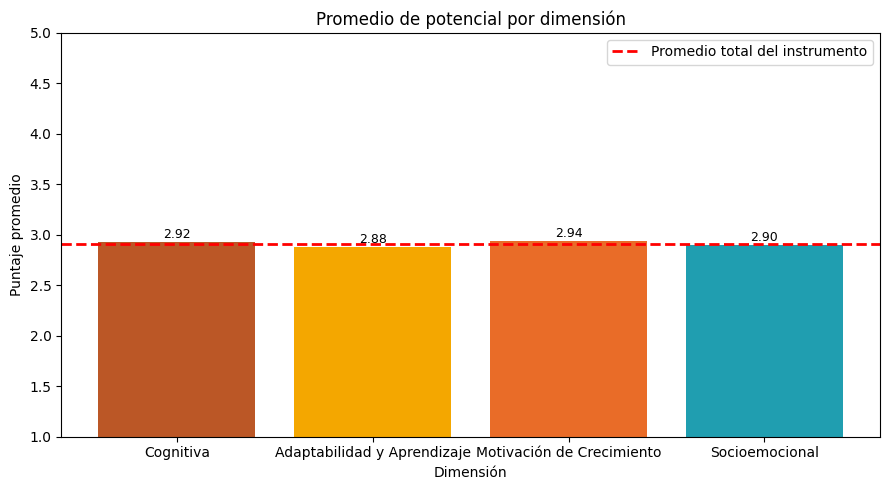

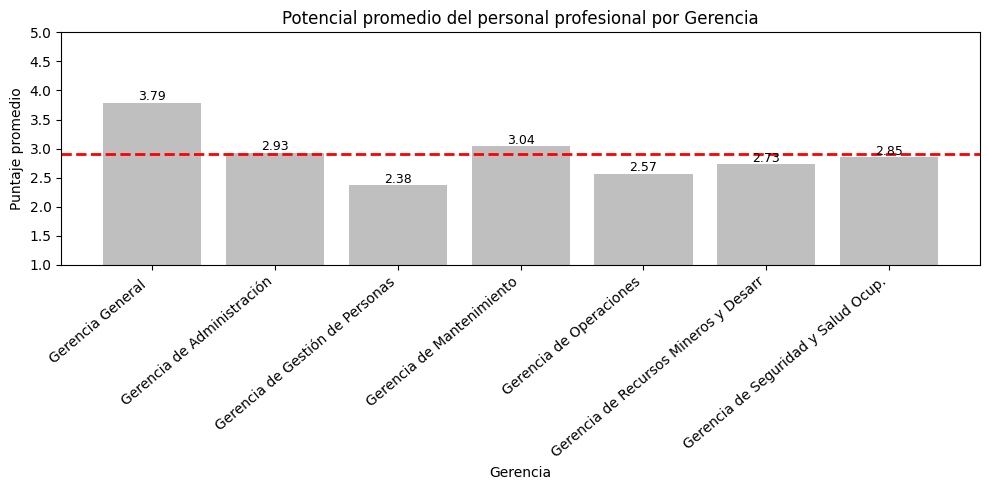

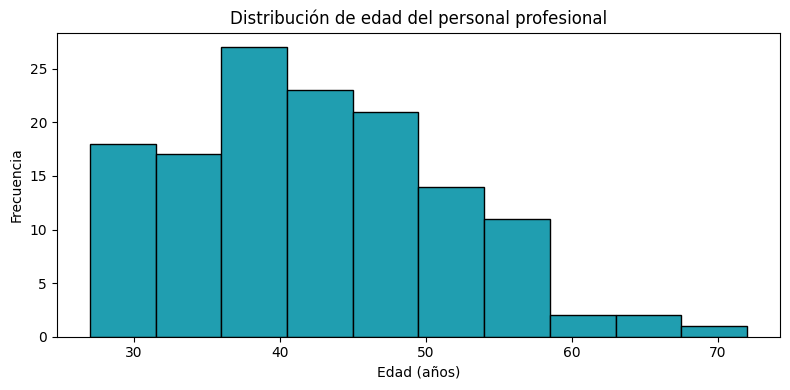

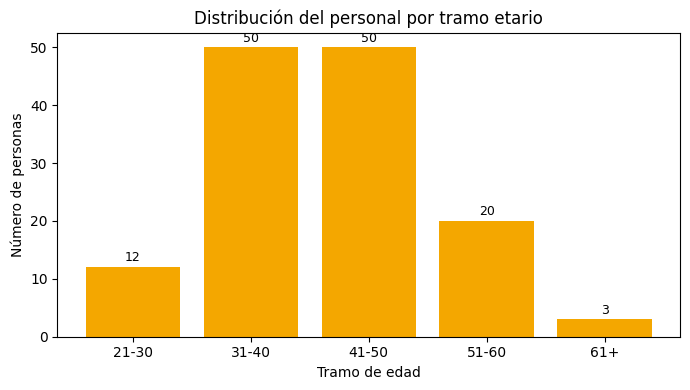

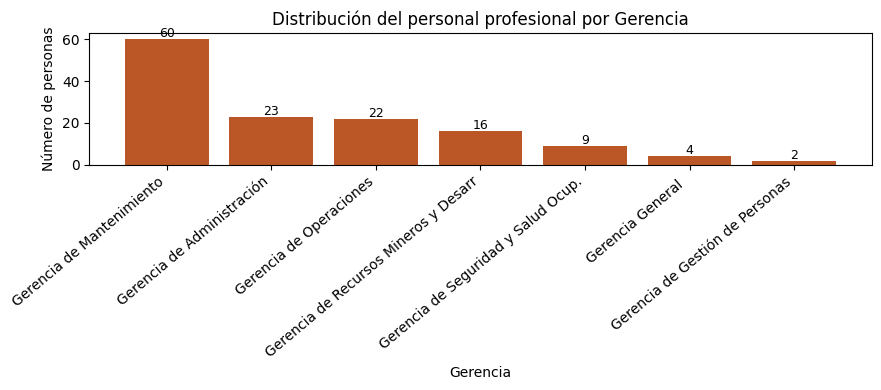

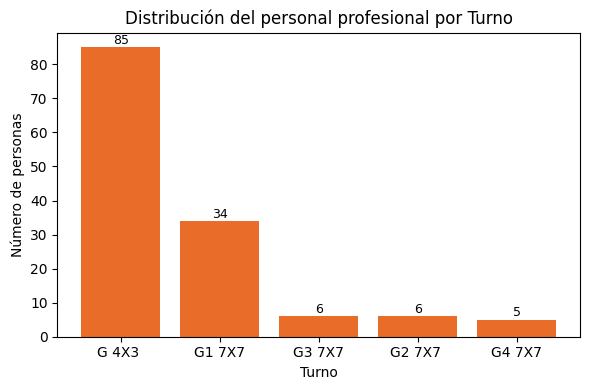

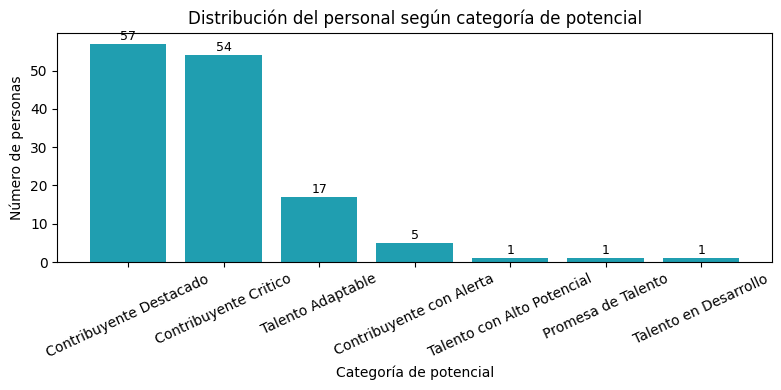

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 1. CARGA DE DATOS
# =====================================================
df = pd.read_excel("/content/RESULTADOS FINAL MEMORIA 1.xlsx")

# Limpieza de nombres de columnas
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace("á","a")
    .str.replace("é","e")
    .str.replace("í","i")
    .str.replace("ó","o")
    .str.replace("ú","u")
)

# =====================================================
# 2. IDENTIFICAR DIMENSIONES
# =====================================================
posibles_dim = [
    "promedio cognitiva",
    "promedio adaptabilidad",
    "promedio motivacion",
    "promedio socioemocional"
]

dimensiones = [c for c in posibles_dim if c in df.columns]

nombres_dim = [
    "Cognitiva",
    "Adaptabilidad y Aprendizaje",
    "Motivación de Crecimiento",
    "Socioemocional"
][:len(dimensiones)]

colores_dim = ["#bb5726", "#f4a700", "#e96c28", "#209eb0"][:len(dimensiones)]

# =====================================================
# 3. VARIABLES GENERALES
# =====================================================
df["potencial_total"] = df[dimensiones].mean(axis=1)

prom_dim = df[dimensiones].mean()
promedio_total = df["potencial_total"].mean()

# =====================================================
# 4. GRÁFICO 1 – PROMEDIO POR DIMENSIÓN + PROMEDIO TOTAL
# =====================================================
plt.figure(figsize=(9,5))
bars = plt.bar(nombres_dim, prom_dim.values, color=colores_dim)

plt.axhline(promedio_total, color="red", linestyle="--",
            linewidth=2, label="Promedio total del instrumento")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.04,
             f"{y:.2f}", ha="center", fontsize=9)

plt.title("Promedio de potencial por dimensión")
plt.ylabel("Puntaje promedio")
plt.xlabel("Dimensión")
plt.ylim(1,5)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 5. GRÁFICO 2 – POTENCIAL PROMEDIO POR GERENCIA
# =====================================================
if "gerencia" in df.columns:
    prom_ger = df.groupby("gerencia")["potencial_total"].mean()

    plt.figure(figsize=(10,5))
    bars = plt.bar(prom_ger.index.astype(str),
                   prom_ger.values, color="#BFBFBF")

    plt.axhline(promedio_total, color="red",
                linestyle="--", linewidth=2)

    for bar in bars:
        y = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, y + 0.04,
                 f"{y:.2f}", ha="center", fontsize=9)

    plt.title("Potencial promedio del personal profesional por Gerencia")
    plt.ylabel("Puntaje promedio")
    plt.xlabel("Gerencia")
    plt.xticks(rotation=40, ha="right")
    plt.ylim(1,5)
    plt.tight_layout()
    plt.show()

# =====================================================
# 6. GRÁFICO 3 – DISTRIBUCIÓN DE EDAD
# =====================================================
if "edad" in df.columns:
    plt.figure(figsize=(8,4))
    plt.hist(df["edad"].dropna(), bins=10,
             color="#209eb0", edgecolor="black")
    plt.title("Distribución de edad del personal profesional")
    plt.xlabel("Edad (años)")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

# =====================================================
# 7. GRÁFICO 4 – TRAMOS DE EDAD
# =====================================================
if "edad" in df.columns:
    df["tramo_edad"] = pd.cut(
        df["edad"],
        bins=[20,30,40,50,60,70],
        labels=["21-30","31-40","41-50","51-60","61+"]
    )

    dist_tramo = df["tramo_edad"].value_counts().sort_index()

    plt.figure(figsize=(7,4))
    bars = plt.bar(dist_tramo.index.astype(str),
                   dist_tramo.values, color="#f4a700")

    for bar in bars:
        y = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, y + 1,
                 int(y), ha="center", fontsize=9)

    plt.title("Distribución del personal por tramo etario")
    plt.ylabel("Número de personas")
    plt.xlabel("Tramo de edad")
    plt.tight_layout()
    plt.show()

# =====================================================
# 8. GRÁFICO 5 – DISTRIBUCIÓN DEL PERSONAL POR GERENCIA
# =====================================================
if "gerencia" in df.columns:
    conteo_ger = df["gerencia"].value_counts()

    plt.figure(figsize=(9,4))
    bars = plt.bar(conteo_ger.index.astype(str),
                   conteo_ger.values, color="#bb5726")

    for bar in bars:
        y = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, y + 1,
                 int(y), ha="center", fontsize=9)

    plt.title("Distribución del personal profesional por Gerencia")
    plt.ylabel("Número de personas")
    plt.xlabel("Gerencia")
    plt.xticks(rotation=40, ha="right")
    plt.tight_layout()
    plt.show()

# =====================================================
# 9. GRÁFICO 6 – DISTRIBUCIÓN DEL PERSONAL POR TURNO
# =====================================================
if "turno" in df.columns:
    conteo_turno = df["turno"].value_counts()

    plt.figure(figsize=(6,4))
    bars = plt.bar(conteo_turno.index.astype(str),
                   conteo_turno.values, color="#e96c28")

    for bar in bars:
        y = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, y + 1,
                 int(y), ha="center", fontsize=9)

    plt.title("Distribución del personal profesional por Turno")
    plt.ylabel("Número de personas")
    plt.xlabel("Turno")
    plt.tight_layout()
    plt.show()

# =====================================================
# 10. GRÁFICO 7 – DISTRIBUCIÓN GENERAL POR CATEGORÍA DE TALENTO
# =====================================================
col_categoria = None
for c in df.columns:
    if any(k in c for k in ["categoria", "talento", "clasificacion", "nine"]):
        col_categoria = c

if col_categoria:
    dist_cat = df[col_categoria].value_counts()

    plt.figure(figsize=(8,4))
    bars = plt.bar(dist_cat.index.astype(str),
                   dist_cat.values, color="#209eb0")

    for bar in bars:
        y = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, y + 1,
                 int(y), ha="center", fontsize=9)

    plt.title("Distribución del personal según categoría de potencial")
    plt.ylabel("Número de personas")
    plt.xlabel("Categoría de potencial")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

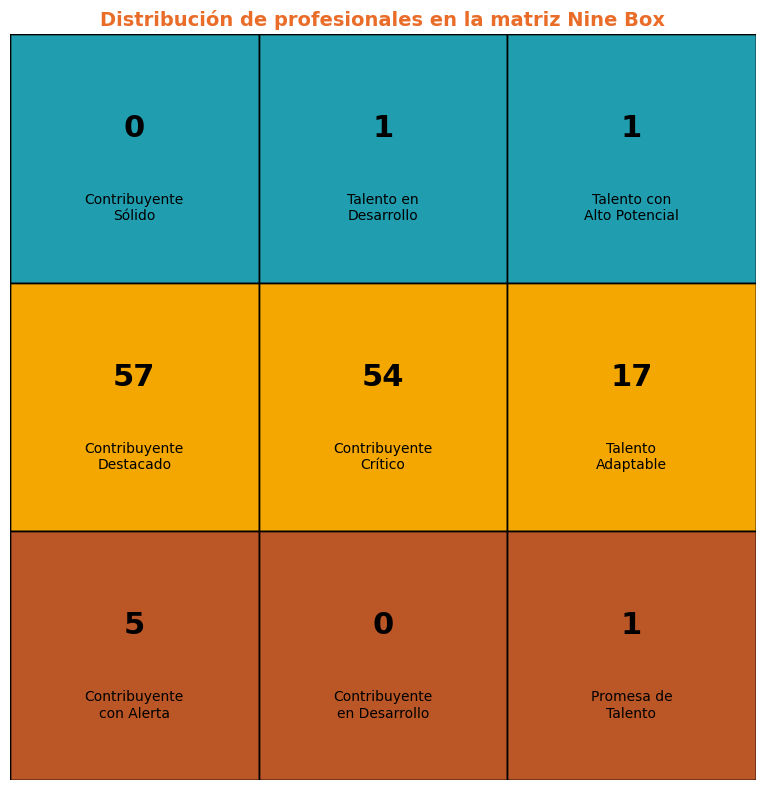

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 1. CARGA DE DATOS
# =====================================================
df = pd.read_excel("/content/RESULTADOS FINAL MEMORIA 1.xlsx")

# Tomar columna AB (índice 27) con clasificación Nine Box
df["ninebox"] = (
    df.iloc[:, 27]
    .astype(str)
    .str.strip()
    .str.lower()
)

# =====================================================
# 2. DEFINICIÓN DE CUADRANTES NINE BOX
# (Y = Desempeño / X = Potencial)
# =====================================================
ninebox_layout = {
    (2, 0): "contribuyente solido",
    (2, 1): "talento en desarrollo",
    (2, 2): "talento con alto potencial",

    (1, 0): "contribuyente destacado",
    (1, 1): "contribuyente critico",
    (1, 2): "talento adaptable",

    (0, 0): "contribuyente con alerta",
    (0, 1): "contribuyente en desarrollo",
    (0, 2): "promesa de talento"
}

# Nombres formales
nombres_formales = {
    "contribuyente solido": "Contribuyente\nSólido",
    "talento en desarrollo": "Talento en\nDesarrollo",
    "talento con alto potencial": "Talento con\nAlto Potencial",
    "contribuyente destacado": "Contribuyente\nDestacado",
    "contribuyente critico": "Contribuyente\nCrítico",
    "talento adaptable": "Talento\nAdaptable",
    "contribuyente con alerta": "Contribuyente\ncon Alerta",
    "contribuyente en desarrollo": "Contribuyente\nen Desarrollo",
    "promesa de talento": "Promesa de\nTalento"
}

# =====================================================
# 3. COLORES CODELCO – EXACTOS (SIN MODIFICAR)
# =====================================================
color_fila = {
    2: "#209eb0",  # Desempeño alto
    1: "#f4a700",  # Desempeño medio
    0: "#bb5726"   # Desempeño bajo
}

# =====================================================
# 4. CONTAR PERSONAS POR CATEGORÍA
# =====================================================
conteo = df["ninebox"].value_counts()

# =====================================================
# 5. DIBUJO DE LA MATRIZ NINE BOX
# =====================================================
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 3)
ax.set_ylim(0, 3)

# Líneas de la matriz
for i in range(4):
    ax.axhline(i, color="black", linewidth=1)
    ax.axvline(i, color="black", linewidth=1)

# Dibujar cuadrantes
for (y, x), categoria in ninebox_layout.items():
    cantidad = conteo.get(categoria, 0)

    # Fondo con color EXACTO
    ax.add_patch(
        plt.Rectangle(
            (x, y),
            1,
            1,
            facecolor=color_fila[y],
            edgecolor="black"
        )
    )

    # Número grande
    ax.text(
        x + 0.5,
        y + 0.62,
        str(cantidad),
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold",
        color="black"
    )

    # Nombre del cuadrante
    ax.text(
        x + 0.5,
        y + 0.30,
        nombres_formales[categoria],
        ha="center",
        va="center",
        fontsize=10,
        color="black"
    )

# Etiquetas de ejes
ax.set_xticks([0.5, 1.5, 2.5])
ax.set_xticklabels(["Bajo", "Medio", "Alto"], fontsize=11)
ax.set_yticks([0.5, 1.5, 2.5])
ax.set_yticklabels(["Bajo", "Medio", "Alto"], fontsize=11)

ax.set_xlabel("Potencial", fontsize=12)
ax.set_ylabel("Desempeño", fontsize=12)

ax.set_title(
    "Distribución de profesionales en la matriz Nine Box",
    fontsize=14,
    fontweight="bold",
    color="#e96c28"  # CUARTO COLOR CODELCO
)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
plt.show()

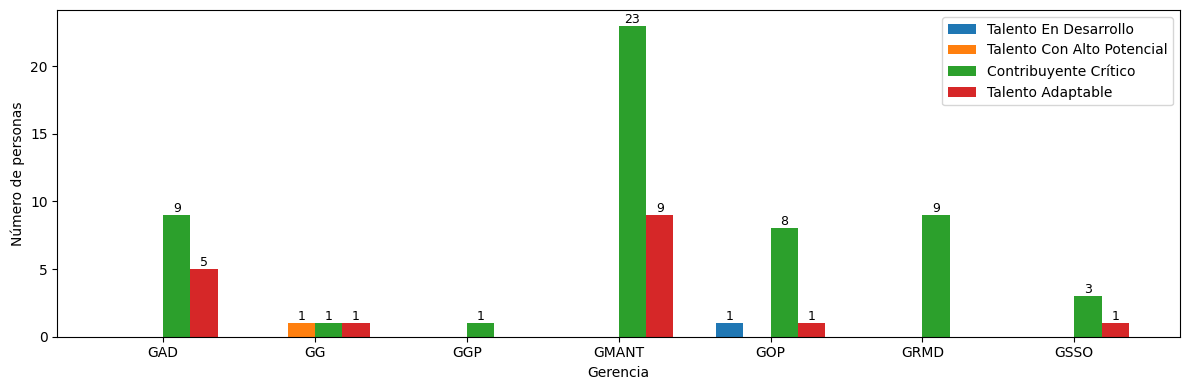

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Gerencias
gerencias = ['GAD', 'GG', 'GGP', 'GMANT', 'GOP', 'GRMD', 'GSSO']

# Datos por categoría
talento_desarrollo = [0, 0, 0, 0, 1, 0, 0]
alto_potencial =     [0, 1, 0, 0, 0, 0, 0]
contribuyente =      [9, 1, 1, 23, 8, 9, 3]
talento_adaptable =  [5, 1, 0, 9, 1, 0, 1]

# Posiciones
x = np.arange(len(gerencias))
width = 0.18

# Gráfico
fig, ax = plt.subplots(figsize=(12, 4))

bars1 = ax.bar(x - 1.5*width, talento_desarrollo, width, label='Talento En Desarrollo')
bars2 = ax.bar(x - 0.5*width, alto_potencial, width, label='Talento Con Alto Potencial')
bars3 = ax.bar(x + 0.5*width, contribuyente, width, label='Contribuyente Crítico')
bars4 = ax.bar(x + 1.5*width, talento_adaptable, width, label='Talento Adaptable')

# Etiquetas
ax.set_ylabel('Número de personas')
ax.set_xlabel('Gerencia')
ax.set_xticks(x)
ax.set_xticklabels(gerencias)
ax.legend()

# Valores sobre las barras
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

plt.tight_layout()
plt.show()